In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import tensorflow as tf

mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Times New Roman', 'Liberation Serif', 'Times', 'DejaVu Serif']
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['axes.titlesize'] = 13
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['xtick.labelsize'] = 10
mpl.rcParams['ytick.labelsize'] = 10
mpl.rcParams['legend.fontsize'] = 10
mpl.rcParams['font.size'] = 11

def save_eps(fig, filename):
    fig.savefig(f"{filename}.eps", format='eps', dpi=600, bbox_inches='tight')
    print(f"Saved: {filename}.eps")

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]])
y = np.array([0, 1, 1, 0])

print("XOR inputs:\n", X)
print("XOR targets:\n", y)

XOR inputs:
 [[0 0]
 [0 1]
 [1 0]
 [1 1]]
XOR targets:
 [0 1 1 0]


In [ ]:
weights = np.zeros(2)
bias = 0.0
learning_rate = 0.1
max_epochs = 20

def step_activation(z):
    return 1 if z >= 0 else 0

update_history = []
update_history.append((weights.copy(), bias, 0, -1, None, None, None))

converged = False
for epoch in range(1, max_epochs + 1):
    epoch_errors = 0
    for i in range(len(X)):
        x_i = X[i]
        target = y[i]
        z = np.dot(weights, x_i) + bias
        pred = step_activation(z)
        error = target - pred

        if error != 0:
            weights = weights + learning_rate * error * x_i
            bias = bias + learning_rate * error
            epoch_errors += 1
            update_history.append((weights.copy(), bias, epoch, i, x_i, target, pred))

    if epoch_errors == 0:
        converged = True
        break

print("Weight updates (Perceptron Learning Algorithm on XOR):\n")
print(f"{'Update #':<10}{'Epoch':<8}{'Sample':<20}{'Target':<8}{'Pred':<6}{'Weights':<20}{'Bias':<10}")
for idx, (w, b, epoch, sample_i, x_i, target, pred) in enumerate(update_history):
    if idx == 0:
        print(f"{idx:<10}{'-':<8}{'initial':<20}{'-':<8}{'-':<6}{str(w):<20}{b:<10.3f}")
    else:
        print(f"{idx:<10}{epoch:<8}{str(x_i):<20}{target:<8}{pred:<6}{str(np.round(w,3)):<20}{b:<10.3f}")

print(f"\nConverged: {converged}")
print(f"Total updates: {len(update_history) - 1}")
print(f"Stopped after {epoch if not converged else epoch} epoch(s) (max_epochs = {max_epochs})")

Weight updates (Perceptron Learning Algorithm on XOR):

Update #  Epoch   Sample              Target  Pred  Weights             Bias      
0         -       initial             -       -     [0. 0.]             0.000     
1         1       [0 0]               0       1     [0. 0.]             -0.100    
2         1       [0 1]               1       0     [0.  0.1]           0.000     
3         1       [1 1]               0       1     [-0.1  0. ]         -0.100    
4         2       [0 1]               1       0     [-0.1  0.1]         0.000     
5         2       [1 0]               1       0     [0.  0.1]           0.100     
6         2       [1 1]               0       1     [-0.1  0. ]         0.000     
7         3       [0 0]               0       1     [-0.1  0. ]         -0.100    
8         3       [0 1]               1       0     [-0.1  0.1]         0.000     
9         3       [1 0]               1       0     [0.  0.1]           0.100     
10        3       [1 1]        

Saved: perceptron_xor_decision_boundary_evolution.eps


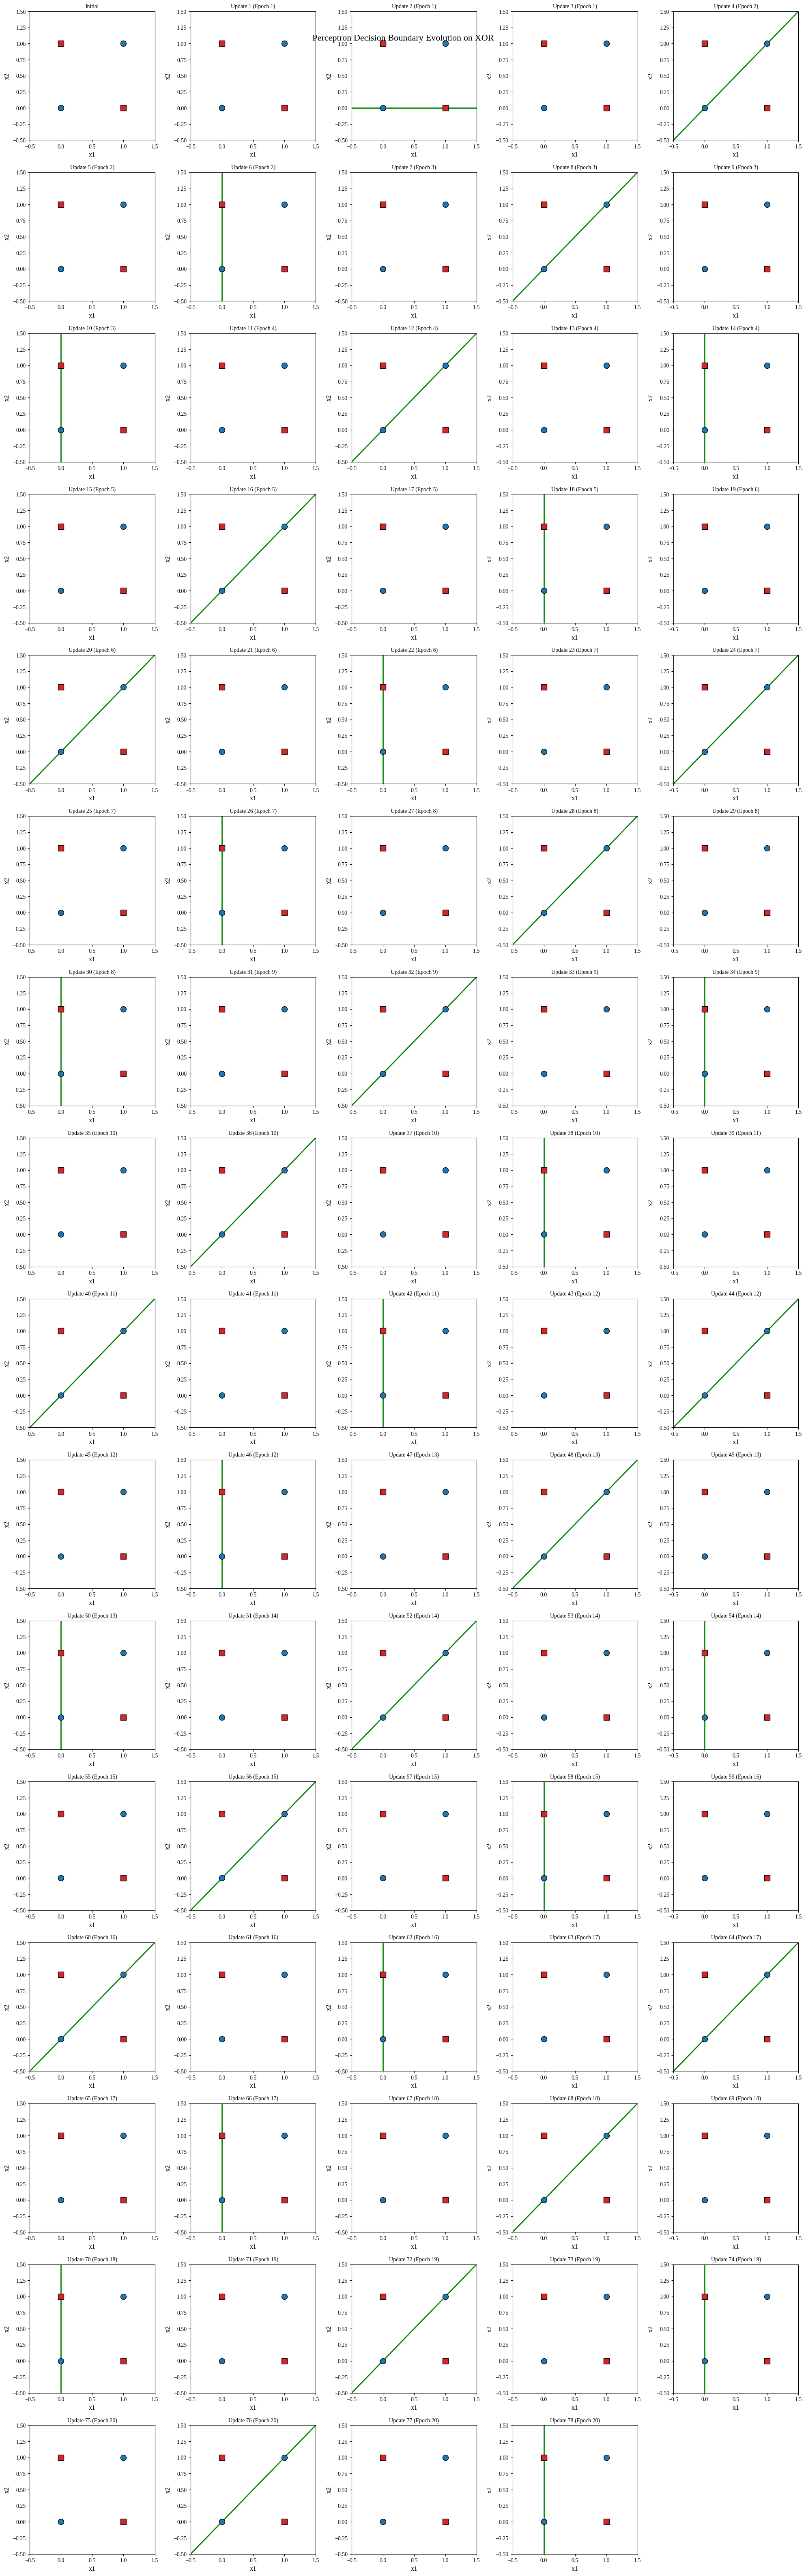

In [ ]:
n_updates = len(update_history)
n_cols = 5
n_rows = int(np.ceil(n_updates / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = np.array(axes).reshape(-1)

x_range = np.linspace(-0.5, 1.5, 100)

for idx, (w, b, epoch, sample_i, x_i, target, pred) in enumerate(update_history):
    ax = axes[idx]

    for xi, yi in zip(X, y):
        color = 'tab:blue' if yi == 0 else 'tab:red'
        marker = 'o' if yi == 0 else 's'
        ax.scatter(xi[0], xi[1], c=color, marker=marker, s=100, edgecolors='black', zorder=3)

    if abs(w[1]) > 1e-8:
        y_vals = -(w[0] * x_range + b) / w[1]
        ax.plot(x_range, y_vals, color='green', linewidth=2)
    elif abs(w[0]) > 1e-8:
        x_vert = -b / w[0]
        ax.axvline(x_vert, color='green', linewidth=2)

    title = "Initial" if idx == 0 else f"Update {idx} (Epoch {epoch})"
    ax.set_title(title, fontfamily='serif', fontsize=10)
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel("x1", fontfamily='serif')
    ax.set_ylabel("x2", fontfamily='serif')

for j in range(n_updates, len(axes)):
    axes[j].axis('off')

fig.suptitle("Perceptron Decision Boundary Evolution on XOR", fontfamily='serif', fontsize=16)
plt.tight_layout()
save_eps(fig, "perceptron_xor_decision_boundary_evolution")
plt.show()

In [ ]:
X_mlp = X.astype(np.float32)
y_mlp = y.reshape(-1, 1).astype(np.float32)

tf.random.set_seed(SEED)

xor_mlp_model = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation='sigmoid', input_shape=(2,), name="Hidden_Layer"),
    tf.keras.layers.Dense(1, activation='sigmoid', name="Output_Layer")
])

xor_mlp_model.summary()

optimizer = tf.keras.optimizers.Adam(learning_rate=0.1)
loss_fn = tf.keras.losses.BinaryCrossentropy()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer (Dense)            │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)


 Epoch 10/100 | Loss: 0.6871

--- kernel ---
[[ 1.5153 -0.6654  0.5149  0.0153]
 [ 1.6222 -0.0456  0.2525 -1.2752]]

--- bias ---
[-0.0088 -0.7881 -0.2392 -0.7049]

--- kernel ---
[[ 0.2612]
 [ 0.0954]
 [-0.7378]
 [ 0.0224]]

--- bias ---
[0.0942]

 Epoch 25/100 | Loss: 0.6506

--- kernel ---
[[ 3.1358 -1.1282  0.4146 -0.164 ]
 [ 3.2492 -0.2059  0.2227 -1.6914]]

--- bias ---
[-0.7881 -1.2827 -0.2727 -1.1382]

--- kernel ---
[[ 0.8354]
 [-0.0714]
 [-0.838 ]
 [-0.0473]]

--- bias ---
[-0.0877]

 Epoch 50/100 | Loss: 0.4839

--- kernel ---
[[ 6.1554 -1.9435  1.1431 -2.3733]
 [ 6.2684 -1.9432  0.955  -2.5324]]

--- bias ---
[-2.3031 -1.1909 -0.7848 -0.7596]

--- kernel ---
[[ 2.6895]
 [-0.41  ]
 [-1.9244]
 [-0.53  ]]

--- bias ---
[-0.8687]

 Epoch 100/100 | Loss: 0.0448

--- kernel ---
[[ 8.5052 -5.9902  4.7294 -7.4416]
 [ 8.6195 -5.8788  4.732  -7.7073]]

--- bias ---
[-2.921   1.391  -6.9052  2.297 ]

--- kernel ---
[[ 4.9768]
 [-1.5334]
 [-6.8956]
 [-2.8823]]

--- bias ---
[-1.1641]


Saved: mlp_xor_decision_boundary_evolution.eps


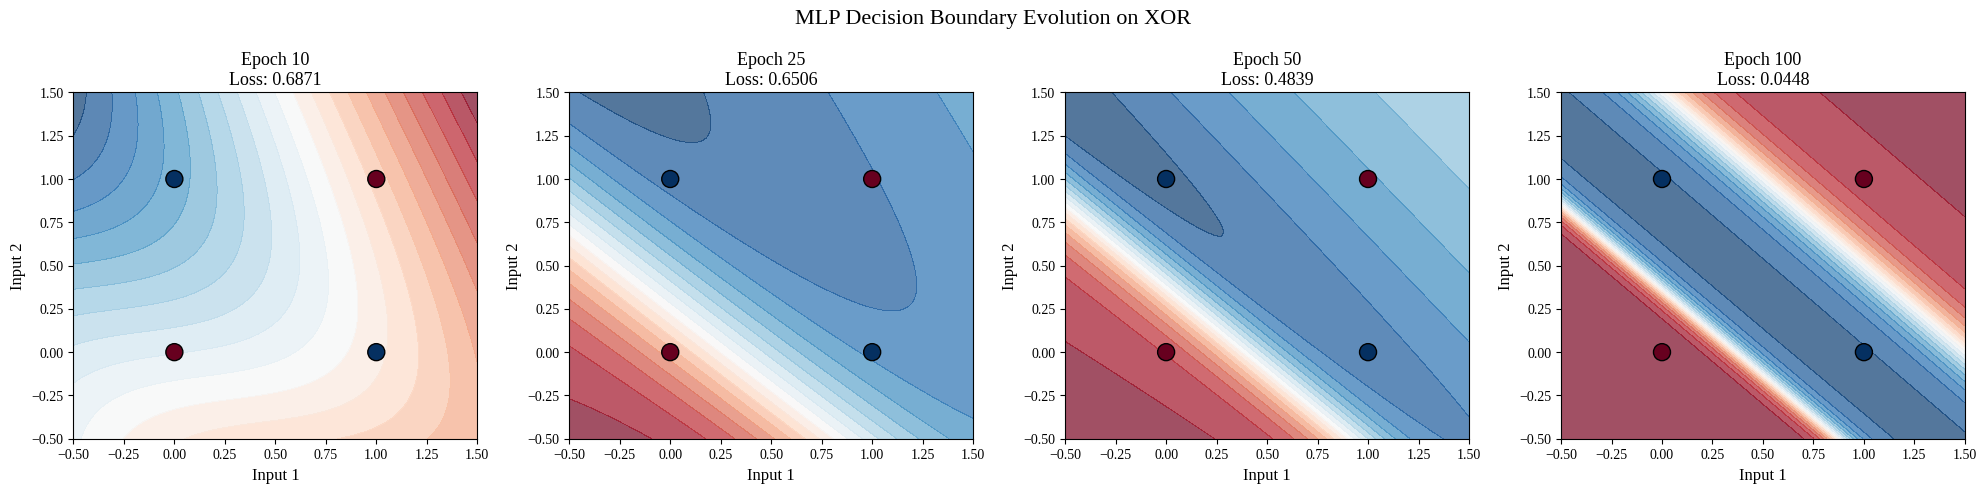


Final predictions: [0 1 1 0]
True labels      : [0 1 1 0]
MLP correctly classifies XOR: True


In [ ]:
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 100), np.linspace(-0.5, 1.5, 100))
grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)

epochs = 100
target_epochs = [10, 25, 50, 100]
mlp_loss_history = []

fig, axes = plt.subplots(1, len(target_epochs), figsize=(5 * len(target_epochs), 5))

plot_idx = 0
for epoch in range(epochs):
    with tf.GradientTape() as tape:
        predictions = xor_mlp_model(X_mlp)
        loss = loss_fn(y_mlp, predictions)

    gradients = tape.gradient(loss, xor_mlp_model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, xor_mlp_model.trainable_variables))
    mlp_loss_history.append(loss.numpy())

    if (epoch + 1) in target_epochs:
        print(f"\n{'='*40}")
        print(f" Epoch {epoch + 1}/{epochs} | Loss: {loss.numpy():.4f}")
        print(f"{'='*40}")
        for var in xor_mlp_model.trainable_variables:
            print(f"\n--- {var.name} ---")
            print(np.round(var.numpy(), 4))

        ax = axes[plot_idx]
        preds_grid = xor_mlp_model(grid).numpy().reshape(xx.shape)
        cf = ax.contourf(xx, yy, preds_grid, levels=20, cmap='RdBu', alpha=0.7)
        ax.scatter(X_mlp[:, 0], X_mlp[:, 1], c=y_mlp[:, 0], cmap='RdBu',
                   edgecolors='black', s=150, zorder=5)
        ax.set_title(f"Epoch {epoch + 1}\nLoss: {loss.numpy():.4f}", fontfamily='serif')
        ax.set_xlabel("Input 1", fontfamily='serif')
        ax.set_ylabel("Input 2", fontfamily='serif')
        ax.set_xlim(-0.5, 1.5)
        ax.set_ylim(-0.5, 1.5)
        plot_idx += 1

fig.suptitle("MLP Decision Boundary Evolution on XOR", fontfamily='serif', fontsize=16)
plt.tight_layout()
save_eps(fig, "mlp_xor_decision_boundary_evolution")
plt.show()

final_preds = (xor_mlp_model(X_mlp).numpy() > 0.5).astype(int).flatten()
print(f"\nFinal predictions: {final_preds}")
print(f"True labels      : {y_mlp.flatten().astype(int)}")
print(f"MLP correctly classifies XOR: {np.array_equal(final_preds, y_mlp.flatten().astype(int))}")

Saved: mlp_xor_loss_curve.eps


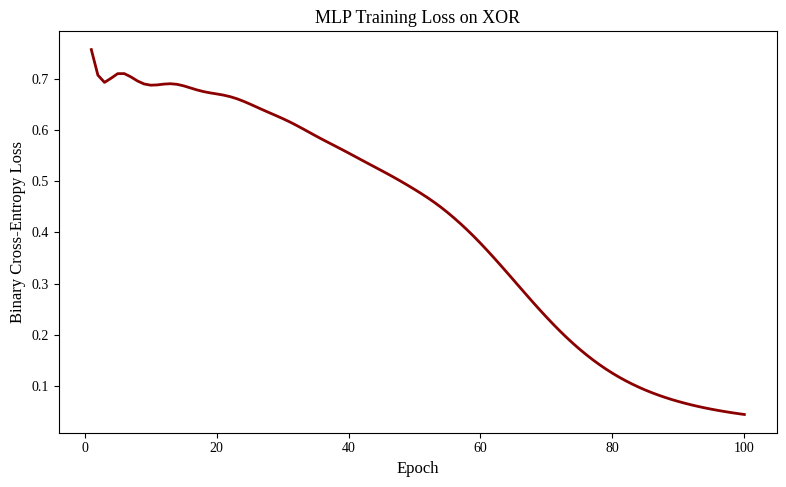

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, epochs + 1), mlp_loss_history, color='darkred', linewidth=2)
ax.set_xlabel("Epoch", fontfamily='serif')
ax.set_ylabel("Binary Cross-Entropy Loss", fontfamily='serif')
ax.set_title("MLP Training Loss on XOR", fontfamily='serif')
plt.tight_layout()
save_eps(fig, "mlp_xor_loss_curve")
plt.show()

